# R&E 연구 검증 방법론 2편: Two Features (이변량 분석)

변수 **2개**를 골라서 "둘 사이에 관계가 있는가?"를 분석하는 단계.
연구의 핵심이다. **"X가 Y에 영향을 미치는가?"**에 답한다.

두 변수의 타입 조합에 따라 방법이 완전히 달라진다:

```
2-Feature
|
|-- [A] 수치 vs 수치
|     |-- 관계 유무: 상관분석 (Pearson / Spearman)
|     |-- 예측/영향: 선형 회귀, 다항 회귀
|     |-- 정보량: 상호정보량 (Mutual Information)
|
|-- [B] 범주 vs 수치
|     |-- 그룹 2개: t-test (모수) / Mann-Whitney (비모수)
|     |-- 그룹 3개+: ANOVA (모수) / Kruskal-Wallis (비모수)
|     |-- 사후검정: Tukey HSD
|     |-- 효과 크기: Cohen's d, Eta-squared
|
|-- [C] 범주 vs 범주
|     |-- 카이제곱 독립성 검정
|     |-- Fisher 정확 검정 (소표본)
|     |-- Cramer's V (효과 크기)
```

### 검정 선택 핵심 결정: 모수 vs 비모수

**1편에서 정규성 검정을 해야 하는 이유가 여기서 나온다.**

| 조건 | 모수 검정 (Parametric) | 비모수 검정 (Non-parametric) |
|------|----------------------|---------------------------|
| 정규분포 O | t-test, ANOVA, Pearson r | (사용 가능하지만 불필요) |
| 정규분포 X | (부적절) | Mann-Whitney, Kruskal-Wallis, Spearman rho |
| 표본 크기 | 충분히 클 때 (n>30 근사) | 작을 때도 안전 |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

df = sns.load_dataset('penguins').dropna()
print(f'데이터 수: {len(df)}')
df.head()

데이터 수: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


---
## 2-A. 수치 vs 수치

두 변수가 모두 숫자일 때. "하나가 올라가면 다른 것도 올라가는가?"

| 방법 | 질문 | 결과 |
|------|------|------|
| 산점도 | 관계가 있어 보이는가? | 시각적 판단 |
| **Pearson r** | 선형 관계의 강도와 방향 | -1 ~ +1 (정규분포 가정) |
| **Spearman rho** | 단조 관계의 강도와 방향 | -1 ~ +1 (비모수, 순위 기반) |
| 선형 회귀 | X가 1 늘면 Y가 얼마나 변하는가? | 회귀식, R-squared |
| 상호정보량 | 비선형 관계까지 포함한 의존성 | 0 이상 (클수록 의존적) |

### 상관 해석 기준
| r 범위 | 해석 |
|---------|------|
| 0.0 ~ 0.1 | 무시할 수준 |
| 0.1 ~ 0.3 | 약한 상관 |
| 0.3 ~ 0.5 | 중간 상관 |
| 0.5 ~ 0.7 | 강한 상관 |
| 0.7 ~ 1.0 | 매우 강한 상관 |

### Agent 지시 예시
> "flipper_length_mm와 body_mass_g의 산점도를 그리고,
> Pearson과 Spearman 상관계수를 둘 다 구해줘.
> 유의하면 선형 회귀도 해서 회귀식과 R-squared를 알려줘."


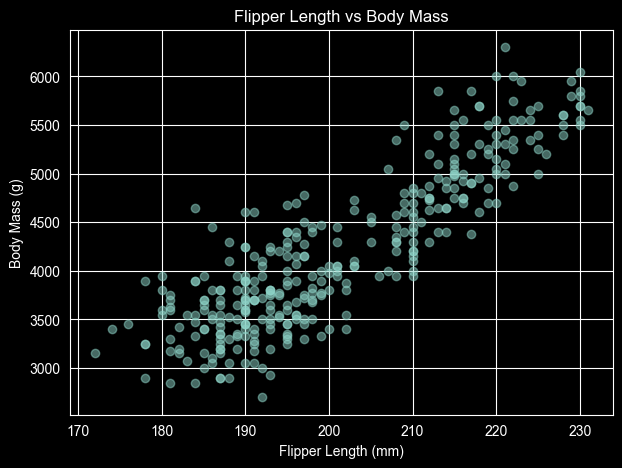

In [2]:
# 산점도: 먼저 눈으로 확인
plt.figure(figsize=(7, 5))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha=0.5)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs Body Mass')
plt.show()

In [3]:
# Pearson vs Spearman 상관분석
x = df['flipper_length_mm']
y = df['body_mass_g']

r_pearson, p_pearson = stats.pearsonr(x, y)
r_spearman, p_spearman = stats.spearmanr(x, y)

print('=== 상관분석: flipper_length vs body_mass ===')
print(f'  Pearson  r={r_pearson:.3f},  p={p_pearson:.2e}  (선형 관계, 정규분포 가정)')
print(f'  Spearman rho={r_spearman:.3f}, p={p_spearman:.2e}  (단조 관계, 비모수)')
print()

# Pearson과 Spearman이 비슷하면: 선형 관계
# Spearman >> Pearson이면: 비선형이지만 단조적 관계
diff = abs(r_spearman) - abs(r_pearson)
if abs(diff) < 0.05:
    print('  -> 두 값이 비슷: 관계가 대체로 선형적')
elif diff > 0.05:
    print('  -> Spearman > Pearson: 비선형이지만 단조적 관계 가능성')
else:
    print('  -> Pearson > Spearman: 이상치의 영향 가능성')

=== 상관분석: flipper_length vs body_mass ===
  Pearson  r=0.873,  p=3.13e-105  (선형 관계, 정규분포 가정)
  Spearman rho=0.840, p=4.63e-90  (단조 관계, 비모수)

  -> 두 값이 비슷: 관계가 대체로 선형적


In [ ]:
# 선형 회귀
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['flipper_length_mm']]
y = df['body_mass_g']

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

print('=== 선형 회귀 ===')
print(f'  회귀식: body_mass = {model.coef_[0]:.2f} * flipper_length + ({model.intercept_:.2f})')
print(f'  R-squared: {r2_score(y, y_pred):.3f}')
print(f'  해석: 날개가 1mm 길어지면 체중이 약 {model.coef_[0]:.1f}g 증가하는 경향')
print(f'        모델이 체중 변동의 {r2_score(y, y_pred)*100:.1f}%를 설명')

# 회귀선 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.4, label='data')
plt.plot(X, y_pred, color='red', linewidth=2, label='regression')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title(f'Linear Regression (R2={r2_score(y, y_pred):.3f})')
plt.legend()
plt.show()

### 상관 vs 회귀: 뭐가 다른가?

| | 상관분석 | 회귀분석 |
|--|---------|--------|
| 질문 | 관계가 **있는가**? 얼마나 강한가? | X로 Y를 **예측**할 수 있는가? |
| 방향성 | X<->Y 대칭 (누가 원인인지 모름) | X->Y 방향이 있음 |
| 결과물 | 상관계수 r (-1~1) | 회귀식 (y = ax + b), R-squared |
| 용도 | 탐색적 분석 | 예측, 영향력 정량화 |

### 주의: 상관 != 인과

"아이스크림 판매량과 익사 사고는 r = 0.9"
-> 아이스크림이 익사를 유발하는가? 아니다. 둘 다 **기온(제3변수)** 때문이다.

상관에서 인과를 주장하려면:
1. 시간적 선후관계 (A가 B보다 먼저)
2. 제3의 변수 통제
3. 이론적 메커니즘 설명 가능


### 상관행렬: 수치형 변수 전체를 한눈에

여러 수치형 변수 간의 상관을 한 번에 보는 방법.
변수 쌍을 선정하거나, 다중공선성(multicollinearity)을 확인할 때 유용.

### Agent 지시 예시
> "수치형 변수 전체의 상관행렬을 구하고 히트맵으로 그려줘. 가장 강한 상관 쌍 3개를 알려줘."


In [ ]:
# 상관행렬 히트맵
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 가장 강한 상관 쌍 추출
pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        pairs.append((numeric_cols[i], numeric_cols[j], corr.iloc[i, j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print('=== 상관 강도 순위 ===')
for v1, v2, r in pairs:
    print(f'  {v1} vs {v2}: r={r:.3f}')

In [ ]:
# 상호정보량 (Mutual Information)
# 상관계수가 잡지 못하는 비선형 관계까지 측정
from sklearn.feature_selection import mutual_info_regression

X_mi = df[numeric_cols].values
print('=== 상호정보량 (body_mass_g 기준) ===')
print('  (높을수록 더 많은 정보를 공유)')
print()

mi = mutual_info_regression(
    df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']],
    df['body_mass_g'],
    random_state=42
)
for col, score in zip(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'], mi):
    print(f'  {col:20s}: MI = {score:.3f}')

print()
print('  참고: MI는 0 이상. 선형이든 비선형이든 모든 종류의 의존성을 측정.')
print('  Pearson r는 선형만, Spearman rho는 단조만 잡지만 MI는 제한 없음.')

---
## 2-B. 범주 vs 수치

"그룹에 따라 숫자 값이 다른가?"
범주(그룹)가 몇 개인지에 따라 방법이 갈린다.

```
범주 vs 수치
|
|-- 정규분포 O (모수)
|     |-- 그룹 2개: 독립표본 t-test
|     |-- 그룹 3개+: One-way ANOVA + Tukey 사후검정
|
|-- 정규분포 X (비모수)
      |-- 그룹 2개: Mann-Whitney U
      |-- 그룹 3개+: Kruskal-Wallis + Dunn 사후검정
```

### 핵심 개념
"눈으로 보니 다른 것 같다"는 증거가 안 된다.
검정은 **"이 차이가 우연히 생길 수 있는 정도인가"**를 수치로 판단한다.


### 2-B-1. t-test (그룹 2개, 모수)

| 종류 | 상황 | Python |
|------|------|--------|
| 독립표본 t-test | 서로 다른 두 그룹 비교 | `stats.ttest_ind(a, b)` |
| 대응표본 t-test | 같은 대상의 전후 비교 | `stats.ttest_rel(before, after)` |
| Welch t-test | 두 그룹의 분산이 다를 때 | `stats.ttest_ind(a, b, equal_var=False)` |

### Agent 지시 예시
> "수컷과 암컷 펭귄의 체중에 유의한 차이가 있는지 t-test 해줘.
> 정규성 검정 먼저 하고, p-value와 Cohen's d(효과 크기)도 보고해줘."


In [ ]:
# 시각화로 먼저 확인
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sex', y='body_mass_g')
plt.title('Body Mass by Sex')
plt.show()

In [ ]:
# 독립표본 t-test: 수컷 vs 암컷 체중
male = df[df['sex'] == 'Male']['body_mass_g']
female = df[df['sex'] == 'Female']['body_mass_g']

# 먼저 정규성 확인
_, p_m = stats.shapiro(male)
_, p_f = stats.shapiro(female)
print(f'정규성 검정: Male p={p_m:.4f}, Female p={p_f:.4f}')
if p_m >= 0.05 and p_f >= 0.05:
    print('  -> 둘 다 정규분포 -> t-test 사용 가능')
else:
    print('  -> 정규분포 아님 -> Mann-Whitney도 함께 수행')
print()

# t-test
t_stat, p_value = stats.ttest_ind(male, female)
print('=== t-test: Male vs Female body_mass_g ===')
print(f'  Male   평균: {male.mean():.1f}g  (n={len(male)})')
print(f'  Female 평균: {female.mean():.1f}g  (n={len(female)})')
print(f'  차이: {male.mean() - female.mean():.1f}g')
print(f'  t-statistic: {t_stat:.3f}')
print(f'  p-value: {p_value:.2e}')
if p_value < 0.05:
    print('  -> 유의한 차이가 있다 (p < 0.05)')

In [ ]:
# 효과 크기: Cohen's d
# p-value는 "차이가 있는가?" (Yes/No)
# Cohen's d는 "차이가 얼마나 큰가?" (크기)
# 논문에서는 둘 다 보고해야 한다.

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

d = cohens_d(male, female)
print(f"Cohen's d = {d:.3f}")
print()

# 해석 기준 (Cohen, 1988)
if abs(d) < 0.2:
    size = '작은 효과 (small)'
elif abs(d) < 0.5:
    size = '작은~중간 효과'
elif abs(d) < 0.8:
    size = '중간 효과 (medium)'
else:
    size = '큰 효과 (large)'
print(f'  -> {size}')
print()
print('해석 기준 (Cohen, 1988):')
print('  |d| < 0.2: 작은 효과')
print('  |d| 0.2~0.5: 작은~중간')
print('  |d| 0.5~0.8: 중간 효과')
print('  |d| > 0.8: 큰 효과')

### p-value 올바르게 이해하기

**p-value란**: "차이가 없다고 가정했을 때(귀무가설), 이 정도 차이가 우연히 나올 확률"

| 흔한 오해 | 현실 |
|-----------|------|
| "효과가 있을 확률이 95%" | p-value는 그런 뜻이 아니다 |
| "p가 작을수록 효과가 크다" | 아니다. 효과 크기는 Cohen's d로 본다 |
| "p > 0.05면 차이가 없다" | "없다"가 아니라 "증거가 부족한 것" |
| "p < 0.05면 무조건 의미있다" | 표본이 매우 크면 사소한 차이도 유의하게 나옴 |

**그래서 반드시 효과 크기(effect size)를 함께 보고해야 한다.**


### 2-B-2. Mann-Whitney U (그룹 2개, 비모수)

정규분포를 따르지 않을 때 t-test 대신 사용한다.
순위(rank)를 기반으로 비교하므로 분포 가정이 필요 없다.

### Agent 지시 예시
> "두 그룹의 [측정값]을 Mann-Whitney U 검정으로 비교해줘."


In [ ]:
# Mann-Whitney U (비모수 대안)
u_stat, p_mw = stats.mannwhitneyu(male, female, alternative='two-sided')

print('=== Mann-Whitney U: Male vs Female body_mass_g ===')
print(f'  U-statistic: {u_stat:.1f}')
print(f'  p-value: {p_mw:.2e}')
if p_mw < 0.05:
    print('  -> 유의한 차이가 있다 (비모수 검정)')
print()
print('  t-test와 비교:')
print(f'    t-test p = {p_value:.2e}')
print(f'    Mann-Whitney p = {p_mw:.2e}')
print('  -> 정규분포일 때는 보통 비슷한 결과. 비정규일 때 Mann-Whitney가 더 신뢰할 만함.')

### 2-B-3. ANOVA (그룹 3개+, 모수)

그룹이 3개 이상이면 t-test를 여러 번 하면 **안 된다**.
비교 횟수가 늘수록 우연히 유의한 결과가 나올 확률(1종 오류)이 쌓인다.

**ANOVA**: "이 그룹들 중 적어도 하나가 다른가?"를 한 번에 검정.
유의하면 -> **Tukey 사후검정**으로 어떤 쌍이 다른지 확인.

| 방법 | 조건 | Python |
|------|------|--------|
| One-way ANOVA | 정규분포 + 등분산 | `stats.f_oneway(g1, g2, g3)` |
| Kruskal-Wallis | 비모수 대안 | `stats.kruskal(g1, g2, g3)` |
| Tukey HSD | ANOVA 사후검정 | `pairwise_tukeyhsd()` |

### Agent 지시 예시
> "세 종의 펭귄 날개 길이에 차이가 있는지 ANOVA + Tukey 사후검정 해줘.
> 정규성 안 되면 Kruskal-Wallis도 해줘. eta-squared(효과 크기)도 보고해줘."


In [ ]:
# ANOVA: 3종 비교
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('Flipper Length by Species')
plt.show()

In [ ]:
# One-way ANOVA
adelie = df[df['species'] == 'Adelie']['flipper_length_mm']
chinstrap = df[df['species'] == 'Chinstrap']['flipper_length_mm']
gentoo = df[df['species'] == 'Gentoo']['flipper_length_mm']

f_stat, p_anova = stats.f_oneway(adelie, chinstrap, gentoo)

print('=== One-way ANOVA: species -> flipper_length_mm ===')
print(f'  Adelie:    {adelie.mean():.1f}mm (n={len(adelie)})')
print(f'  Chinstrap: {chinstrap.mean():.1f}mm (n={len(chinstrap)})')
print(f'  Gentoo:    {gentoo.mean():.1f}mm (n={len(gentoo)})')
print(f'  F = {f_stat:.3f}, p = {p_anova:.2e}')
if p_anova < 0.05:
    print('  -> 적어도 한 쌍의 종 간에 유의한 차이 있음')
print()

# 효과 크기: Eta-squared
all_data = pd.concat([adelie, chinstrap, gentoo])
grand_mean = all_data.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [adelie, chinstrap, gentoo])
ss_total = sum((all_data - grand_mean)**2)
eta_sq = ss_between / ss_total
print(f'  Eta-squared = {eta_sq:.3f}')
print(f'  -> 종이 날개 길이 변동의 {eta_sq*100:.1f}%를 설명')
print()
print('  Eta-squared 해석:')
print('    < 0.01: 작은 효과')
print('    0.01~0.06: 중간 효과')
print('    > 0.14: 큰 효과')

In [ ]:
# Tukey 사후검정: 어떤 쌍이 다른가?
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df['flipper_length_mm'], df['species'], alpha=0.05)
print(tukey)
print()
print('reject=True인 쌍: 해당 두 종 사이에 유의한 차이 있음')

In [ ]:
# Kruskal-Wallis (비모수 대안)
h_stat, p_kw = stats.kruskal(adelie, chinstrap, gentoo)

print('=== Kruskal-Wallis (비모수) ===')
print(f'  H = {h_stat:.3f}, p = {p_kw:.2e}')
print()
print('  ANOVA와 비교:')
print(f'    ANOVA p     = {p_anova:.2e}')
print(f'    Kruskal-W p = {p_kw:.2e}')

---
## 2-C. 범주 vs 범주

두 변수가 모두 범주형일 때. "A의 분포가 B에 따라 달라지는가?"

| 방법 | 상황 | Python |
|------|------|--------|
| **카이제곱 검정** | 기대빈도 >= 5인 셀이 대부분 | `stats.chi2_contingency()` |
| **Fisher 정확 검정** | 2x2 표, 소표본 | `stats.fisher_exact()` |
| **Cramer's V** | 효과 크기 | 직접 계산 |

### Agent 지시 예시
> "종(species)과 섬(island)의 교차표를 만들고, 카이제곱 검정과 Cramer's V를 구해줘."


In [ ]:
# 교차표
ct = pd.crosstab(df['species'], df['island'])
print('=== 교차표: species x island ===')
print(ct)
print()

ct.plot(kind='bar', figsize=(8, 4), edgecolor='black')
plt.title('Species x Island')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 카이제곱 검정 + Cramer's V
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

print('=== 카이제곱 독립성 검정 ===')
print(f'  chi2 = {chi2:.3f}')
print(f'  p-value = {p_chi:.2e}')
print(f'  자유도 = {dof}')
if p_chi < 0.05:
    print('  -> 종과 섬 사이에 유의한 관계가 있다')
print()

# Cramer's V (효과 크기)
n = ct.sum().sum()
min_dim = min(ct.shape[0], ct.shape[1]) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V = {cramers_v:.3f}")
print()
print("  Cramer's V 해석:")
print('    < 0.1: 약한 관계')
print('    0.1~0.3: 중간 관계')
print('    > 0.3: 강한 관계')
print()
print('기대빈도 (독립이라면 이렇게 분포했을 것):')
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

---
## 주의사항과 연구 윤리

### 변인 통제

| 용어 | 역할 | 예시 |
|------|------|------|
| 독립변인 (IV) | 내가 의도적으로 바꾸는 것 | 비료의 양 |
| 종속변인 (DV) | 그 결과로 변하는 것 (측정 대상) | 식물의 키 |
| 통제변인 (CV) | 바뀌면 안 되는 것 (고정) | 물의 양, 햇빛 |

핵심: **한 번에 하나만 바꾼다.** 두 가지를 동시에 바꾸면 원인 특정 불가.

### 절대 하면 안 되는 것

| 이름 | 행위 |
|------|------|
| **p-hacking** | 유의한 결과 나올 때까지 분석 방법을 바꾸는 것 |
| **cherry-picking** | 유리한 데이터만 골라서 보고 |
| **HARKing** | 결과 보고 나서 가설을 만들고, 처음부터 그랬던 척 하는 것 |

### 편향 (Bias)

| 종류 | 예시 |
|------|------|
| 선택 편향 | 특정 유형만 골라서 조사 |
| 확증 편향 | 내 가설에 맞는 데이터만 보려는 경향 |
| 생존자 편향 | 살아남은 것만 보고 판단 (탈락자 무시) |


---
## 2편 요약: 이변량 분석 선택 가이드

```
두 변수의 타입은?
|
|-- 수치 vs 수치
|     |-- 시각화: 산점도
|     |-- 관계 유무: Pearson r (정규) / Spearman rho (비모수)
|     |-- 예측: 선형 회귀 -> R-squared, 회귀식
|     |-- 비선형 의존성: 상호정보량 (MI)
|
|-- 범주 vs 수치
|     |-- 시각화: 박스플롯
|     |-- 정규분포 O + 2그룹: t-test + Cohen's d
|     |-- 정규분포 O + 3그룹+: ANOVA + Tukey + eta-squared
|     |-- 정규분포 X + 2그룹: Mann-Whitney U
|     |-- 정규분포 X + 3그룹+: Kruskal-Wallis
|
|-- 범주 vs 범주
      |-- 시각화: 교차표, 막대그래프
      |-- 카이제곱 검정 + Cramer's V
      |-- 소표본 2x2: Fisher 정확 검정
```

### Agent 통합 지시 예시
> "이 데이터에서 [독립변수]와 [종속변수]의 관계를 분석해줘.
> 변수 타입에 맞는 적절한 검정을 골라서 수행하고,
> p-value와 효과 크기를 함께 보고해줘.
> 시각화도 포함해줘."
